# Survival Analysis 

**This notebook analyzes survival in patients with advanced urothelial cancer receiving first-line pembrolizumab versus those receiving carboplatin-based chemotherapy after removal of the top tertile of mortality risk with a gradient-boosting survival model.** 

In [1]:
import numpy as np
import pandas as pd

from flatiron_cleaner import DataProcessorUrothelial

from iptw_survival import IPTWSurvivalEstimator

import matplotlib.pyplot as plt

## Import data 

### Import risk scores

In [2]:
risk_df = pd.read_csv('../outputs/risk_score_df_kfold.csv')

/var/folders/lr/vkkcj_s12115sxc05ly3mshh0000gn/T/ipykernel_49934/829767602.py:1: DtypeWarning: Columns (189,190) have mixed types. Specify dtype option on import or set low_memory=False.
  risk_df = pd.read_csv('../outputs/risk_score_df_kfold.csv')


In [3]:
risk_df = risk_df[['PatientID', 'risk_score']]

In [4]:
risk_df.shape

(13017, 2)

### Import cleaned data from time of first-line treatment 

In [5]:
dtype_map = pd.read_csv('../outputs/final_df_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
df = pd.read_csv('../outputs/final_df.csv', dtype = dtype_map)

In [6]:
df.shape

(6461, 149)

### Import insurance and SES 

In [7]:
insurance_ses_df = pd.read_csv('../outputs/insurance_ses_df.csv')

In [8]:
insurance_ses_df.shape

(6461, 6)

In [9]:
insurance_ses_df['ses_mod'] = insurance_ses_df['ses_mod'].astype('category')

### Import death from time of first-line treatment 

In [10]:
pembro_carbo_df = pd.read_csv('../outputs/full_cohort_carbo.csv')

In [11]:
pembro_carbo_df.head(1)

,PatientID,LineName,StartDate
0,F5AAF96C85477,Pembrolizumab,2021-07-08


In [12]:
pembro_carbo_df.shape

(3712, 3)

In [13]:
processor = DataProcessorUrothelial()

# Process Enhanced_Mortality_V2.csv and use visit, telemedicine, biomarkers, oral, and progression data to determine censoring date 
mortality_df = processor.process_mortality(file_path = '../data/Enhanced_Mortality_V2.csv',
                                           index_date_df = pembro_carbo_df, 
                                           index_date_column = 'StartDate',
                                           visit_path = '../data/Visit.csv', 
                                           telemedicine_path = '../data/Telemedicine.csv', 
                                           biomarkers_path = '../data/Enhanced_AdvUrothelialBiomarkers.csv', 
                                           oral_path = '../data/Enhanced_AdvUrothelial_Orals.csv',
                                           progression_path = '../data/Enhanced_AdvUrothelial_Progression.csv',
                                           drop_dates = False)

2025-05-20 21:04:54,522 - INFO - Successfully read Enhanced_Mortality_V2.csv file with shape: (9040, 2) and unique PatientIDs: 9040
2025-05-20 21:04:54,531 - INFO - Successfully merged Enhanced_Mortality_V2.csv df with index_date_df resulting in shape: (3712, 3) and unique PatientIDs: 3712
2025-05-20 21:04:54,929 - INFO - The following columns ['last_visit_date', 'last_biomarker_date', 'last_oral_date', 'last_progression_date'] are used to calculate the last EHR date
2025-05-20 21:04:54,935 - INFO - Successfully processed Enhanced_Mortality_V2.csv file with final shape: (3712, 6) and unique PatientIDs: 3712. There are 0 out of 3712 patients with missing duration values


In [14]:
mortality_df.head(1)

,PatientID,imported_StartDate,DateOfDeath,event,last_ehr_activity,duration
0,F5AAF96C85477,2021-07-08,NaT,0,2021-09-14,68.0


In [15]:
mortality_df.shape

(3712, 6)

In [16]:
mortality_df = pd.merge(mortality_df, pembro_carbo_df[['PatientID', 'LineName']], on = 'PatientID', how = 'left')

In [17]:
mortality_df.shape

(3712, 7)

### Merge dataframes

In [18]:
df = pd.merge(df, risk_df, on = 'PatientID', how = 'left')

In [19]:
df.shape

(6461, 150)

In [20]:
df = pd.merge(df, insurance_ses_df, on = 'PatientID', how = 'left')

In [21]:
df.shape

(6461, 155)

In [22]:
df = pd.merge(df, mortality_df[['PatientID', 'event', 'duration', 'LineName']], on = 'PatientID', how = 'left')

In [23]:
df.shape

(6461, 158)

In [24]:
df = df.query('duration >= 0')

## Identify cohort and risk group

In [25]:
df['treatment'] = np.where(df['LineName'] == 'Pembrolizumab', 1, 0)

In [26]:
df.treatment.value_counts()

treatment
0    2222
1    1484
Name: count, dtype: int64

In [27]:
low = df.risk_score.quantile(0.67)

In [28]:
df = df.query('risk_score <= @low')

In [29]:
df.shape

(2483, 159)

In [30]:
df.treatment.value_counts()

treatment
0    1608
1     875
Name: count, dtype: int64

## Survial analysis 

### Preprocessing

In [31]:
#df['creatinine_2'] = np.where(df['creatinine'] > 2, 1, 0)

In [32]:
df.groupby(['adv_diagnosis_year', 'treatment']).size().unstack(fill_value=0)

/var/folders/lr/vkkcj_s12115sxc05ly3mshh0000gn/T/ipykernel_49934/868052135.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['adv_diagnosis_year', 'treatment']).size().unstack(fill_value=0)


treatment,0,1
adv_diagnosis_year,,
2011,92,1
2012,125,1
2013,132,2
2014,145,2
2015,193,5
2016,167,17
2017,128,93
2018,105,133
2019,118,167


In [33]:
df['adv_diagnosis_year'] = df['adv_diagnosis_year'].astype(int)

In [34]:
df['before_2020'] = np.where(df['adv_diagnosis_year'] < 2020, 1, 0)

### IPTW

In [35]:
estimator = IPTWSurvivalEstimator()

In [36]:
# We apply stabilized IPTW and clip propensity scores to the [0.01, 0.99] range to reduce the influence of extreme values
estimator.fit(df = df,
              treatment_col = 'treatment',
              cat_var = ['GroupStage_mod', 'ecog_index', 'ses_mod', 'PDL1_status'],
              cont_var = ['days_diagnosis_to_adv', 'age', 'weight_index', 'percent_change_weight', 'albumin', 'creatinine', 'total_bilirubin', 'van_walraven_score', 'risk_score'],
              binary_var = ['Surgery', 'opioid', 'commercial', 'medicaid', 'before_2020'],
              lr_kwargs = {
                  'class_weight': 'balanced',
                  'solver': 'lbfgs',
                  'penalty': 'l2',
                  'max_iter': 1000,
                  'random_state': 42
              },
              clip_bounds = (0.01, 0.99),
              stabilized = True,)

In [37]:
iptw_df = estimator.transform()

In [38]:
ps_fig = estimator.propensity_score_plot(bins = 30)

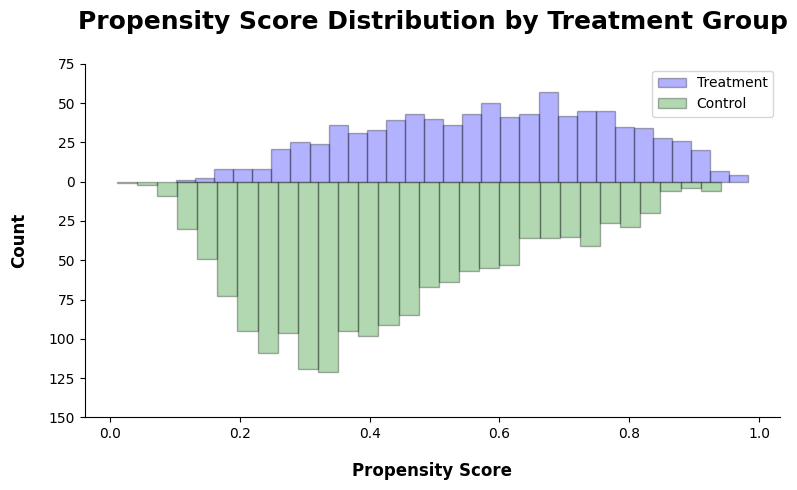

In [39]:
ps_fig

In [40]:
smd_df, smd_fig = estimator.standardized_mean_differences(return_fig = True)

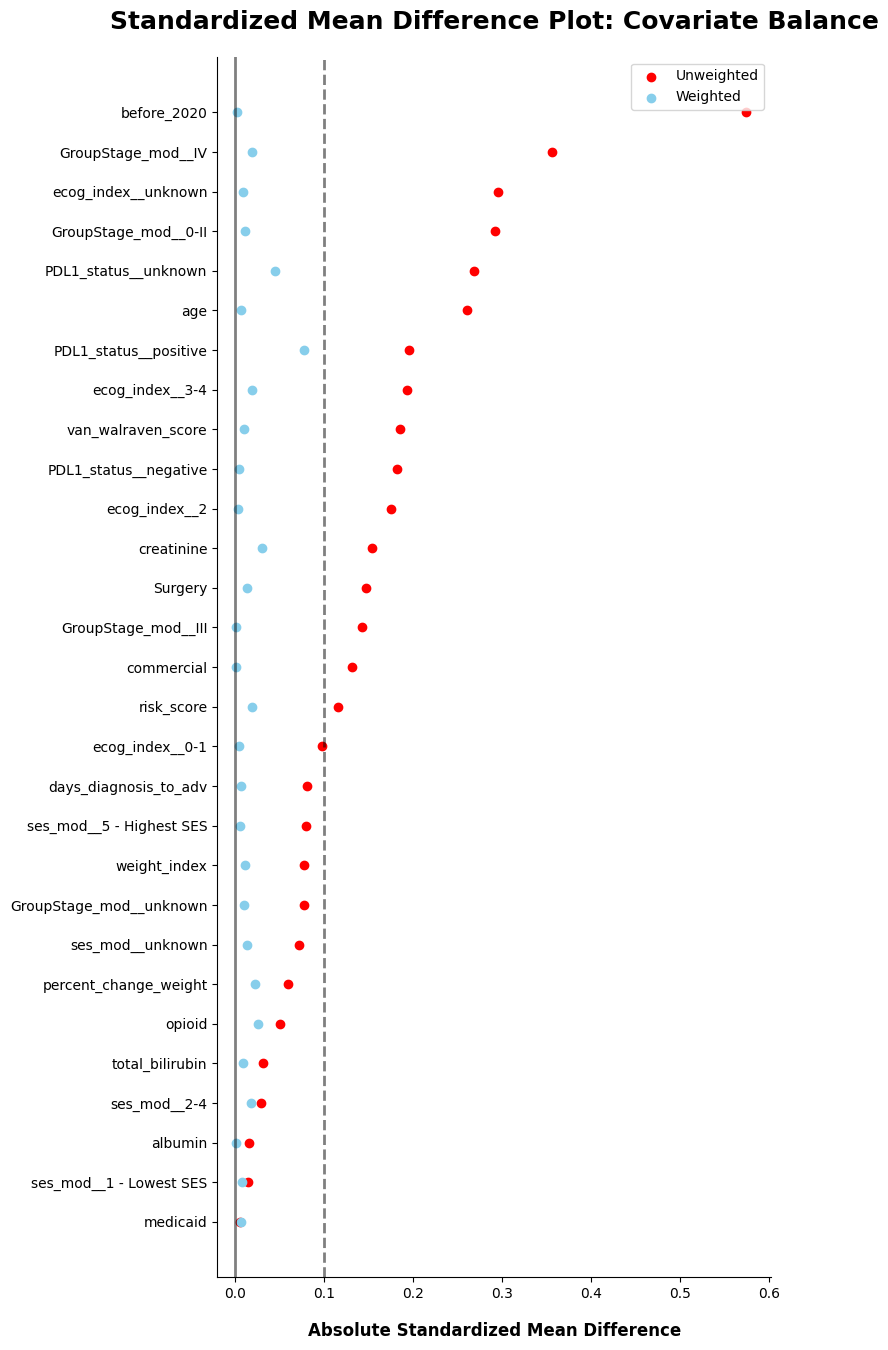

In [41]:
smd_fig

In [42]:
# Convert days to month
iptw_df['duration'] = iptw_df['duration']/30

In [43]:
km_confidence_intervals_df = estimator.km_confidence_intervals(df = iptw_df,
                                                               duration_col = 'duration',
                                                               event_col = 'event',
                                                               weight_col = 'iptw',
                                                               n_bootstrap = 1000,
                                                               random_state = 42)

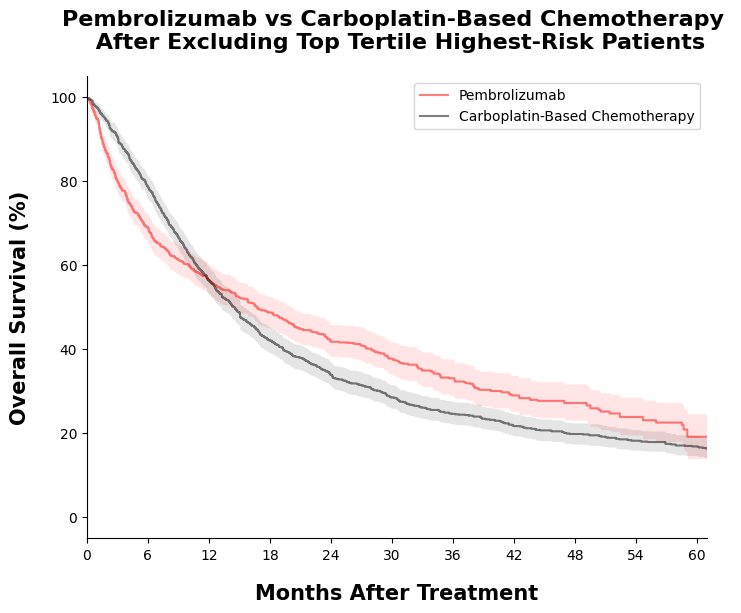

In [44]:
fig = plt.figure(figsize=(8, 6))

# Pembrolizumab arm
# Estimate
plt.step(km_confidence_intervals_df.time, 
         km_confidence_intervals_df.treatment_estimate * 100, 
         color = 'red', 
         alpha = 0.5,
         label = 'Pembrolizumab')

# 95% CI
plt.fill_between(km_confidence_intervals_df.time, 
                 km_confidence_intervals_df.treatment_lower_ci * 100, 
                 km_confidence_intervals_df.treatment_upper_ci * 100, 
                 facecolor = 'red', 
                 alpha = 0.1)

# Chemotherapy arm
# Estimate
plt.step(km_confidence_intervals_df.time, 
         km_confidence_intervals_df.control_estimate * 100, 
         color = 'black', 
         alpha = 0.5,
         label = 'Carboplatin-Based Chemotherapy')

# 95% CI
plt.fill_between(km_confidence_intervals_df.time, 
                 km_confidence_intervals_df.control_lower_ci * 100, 
                 km_confidence_intervals_df.control_upper_ci * 100, 
                 facecolor = 'black', 
                 alpha = 0.1)

plt.xticks(np.arange(0, 61, 6))
plt.xlim(0, 61)

plt.title('Pembrolizumab vs Carboplatin-Based Chemotherapy \n After Excluding Top Tertile Highest-Risk Patients', size = 16, weight = 'bold',  pad = 20)
plt.ylabel('Overall Survival (%)', size = 15, weight = 'bold', labelpad = 15)
plt.xlabel('Months After Treatment', size = 15, weight = 'bold', labelpad = 15)
plt.legend(prop = {'size': 10})

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('../outputs/survival_pembro_carbo_67p.pdf', format = 'pdf', bbox_inches = 'tight')

In [45]:
results = estimator.survival_metrics(df = iptw_df,
                                     duration_col = 'duration',
                                     event_col = 'event',
                                     weight_col = 'iptw',
                                     psurv_time_points = [36, 48],
                                     rmst_time_points = [36, 48],
                                     median_time = True,
                                     n_bootstrap = 1000,
                                     random_state = 42)

In [46]:
# Median results
print('Median Survival Results')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['treatment']['median'])} months')
print(f'Chemotherapy: {tuple(round(x, 1) for x in results['control']['median'])} months')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['median'])} months')

Median Survival Results
Pembrolizumab: (16.8, 14.2, 20.2) months
Chemotherapy: (14.6, 13.3, 15.5) months
Difference: (2.2, -0.4, 5.7) months


In [47]:
# RMST results at 3 years
print('RMST Results at 3 Years')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['treatment']['rmst'][36])} months')
print(f'Chemotherapy: {tuple(round(x, 1) for x in results['control']['rmst'][36])} months')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][36])} months')

# RMST results at 4 years
print('')
print('RMST Results at 4 Years')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['treatment']['rmst'][48])} months')
print(f'Chemotherapy: {tuple(round(x, 1) for x in results['control']['rmst'][48])} months')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][48])} months')

RMST Results at 3 Years
Pembrolizumab: (19.1, 18.1, 20.2) months
Chemotherapy: (18.1, 17.3, 19.0) months
Difference: (1.0, -0.3, 2.3) months

RMST Results at 4 Years
Pembrolizumab: (22.6, 21.2, 24.2) months
Chemotherapy: (20.8, 19.8, 21.9) months
Difference: (1.8, 0.1, 3.6) months


In [48]:
# Probability of survival at 3 years
print('Probability of Survival at 3 Years')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][36])}')
print(f'Chemotherapy: {tuple(round(x, 3) for x in results['control']['survival_prob'][36])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][36])}')

# Probability of survival at 4 years
print('')
print('Probability of Survival at 4 Years')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][48])}')
print(f'Chemotherapy: {tuple(round(x, 3) for x in results['control']['survival_prob'][48])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][48])}')

Probability of Survival at 3 Years
Pembrolizumab: (0.331, 0.29, 0.375)
Chemotherapy: (0.247, 0.221, 0.275)
Difference: (0.085, 0.037, 0.135)

Probability of Survival at 4 Years
Pembrolizumab: (0.272, 0.231, 0.317)
Chemotherapy: (0.199, 0.173, 0.224)
Difference: (0.074, 0.028, 0.125)


**While median survival and RMST were similar between pembrolizumab and chemotherapy, pembrolizumab was associated with slightly better long-term survival probabilities at 3 and 4 years, with statistically significant improvements.**